In [5]:
from sklearn.preprocessing import StandardScaler,RobustScaler,LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

import nltk
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
path = r"D:\Downloads\archive (12)\IMDB Dataset.csv"
df = pd.read_csv(path)

In [7]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [8]:
def remove_punc(text):
    no_punct = "".join([char for char in text if char not in string.punctuation])
    return no_punct


In [9]:
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
def token(text):
  token = word_tokenize(text)
  return token


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\dxbdi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [10]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dxbdi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\dxbdi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\dxbdi\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
stop = nltk.corpus.stopwords.words('english')

def remove_stopwords(text):
    no_stopwords = [word for word in text if word not in stop]
    return no_stopwords
    

In [12]:
wn=nltk.WordNetLemmatizer()

def Lemmatizer(text):
  lemm = [wn.lemmatize(word) for word in text]
  return lemm


In [13]:
def preprocess(text):
    text = text.lower()
    text = remove_punc(text)
    text = word_tokenize(text)
    text = remove_stopwords(text)
    text = Lemmatizer(text)
    return " ".join(text)
df["clean_review"] = df["review"].apply(preprocess)

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
v = TfidfVectorizer()
X = v.fit_transform(df['clean_review'])
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])
y = df['sentiment']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
model = MultinomialNB()
model.fit(X_train,y_train)

MultinomialNB()

In [17]:
print(model.score(X_train,y_train))
print(model.score(X_test,y_test))

0.9154
0.8691


In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.89      0.87      4961
           1       0.88      0.85      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



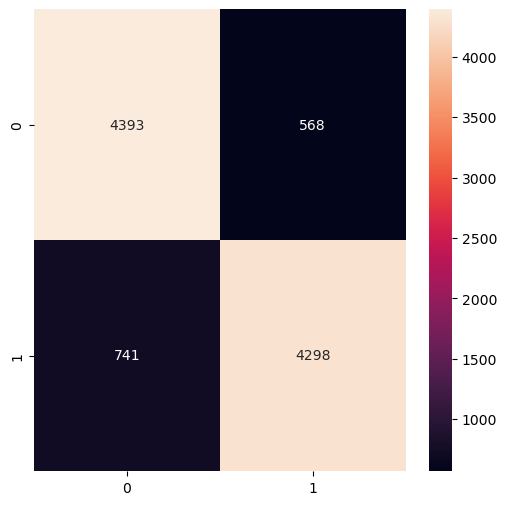

In [20]:
con = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(con,annot=True,fmt='d')
plt.show()

In [21]:
print(accuracy_score(y_test,y_pred))

0.8691


In [22]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(v, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)